In [1]:
from data_readers.green_ppg_reader import read_green_ppg_json

import matplotlib.pyplot as plt
import pandas as pd
from datetime import timedelta
import pytz
import numpy as np

In [2]:
# Read the raw ppg values

path_base ="/"

ppg_files = [
    "green_ppg_data_14-21.json",
    "green_ppg_data_14-22.json",
    "green_ppg_data_14-23.json",
    "green_ppg_data_14-24.json",
    "green_ppg_data_14-25.json",
    "green_ppg_data_14-26.json",
    "green_ppg_data_14-27.json",
    "green_ppg_data_14-28.json",
    "green_ppg_data_14-29.json",
    "green_ppg_data_14-30.json",
    "green_ppg_data_14-31.json",
]

ppg_data = []

for ppg_file in ppg_files:
    ppg_data.append(read_green_ppg_json(path_base + ppg_file))
   
ppg_data = pd.concat(ppg_data)

In [4]:
ppg_ibi_detection = pd.read_csv('data/combined_ppg_bishop_20250717T145946_signals.csv')
ppg_ibi_detection['datetime'] = ppg_data['datetime'].values
ppg_ibi_detection["datetime"] = pd.to_datetime(ppg_ibi_detection["datetime"]).dt.tz_localize("UTC").dt.tz_convert("US/Pacific")
ppg_ibi_detection = ppg_ibi_detection[ppg_ibi_detection['PPG_Peaks'] == 1]
ppg_ibi_detection['ibi'] = ppg_ibi_detection["datetime"].diff(periods=-1).dt.total_seconds() * -1000

In [5]:
ppg_ibi_detection.to_csv("data/combined_ppg_bishop_20250717T145946_cleaned.csv")

In [6]:
ibi_samsung_detected = pd.read_csv('data/ibi_data_forward.csv')
tz = pytz.FixedOffset(-420)
ibi_samsung_detected["datetime"] = pd.to_datetime(ibi_samsung_detected["datetime"])

     Unnamed: 0                         datetime   ibi            ibi_status
0             0 2025-07-16 14:20:57.490000-07:00  1138  HR_IBI_STATUS_NORMAL
1             1 2025-07-16 14:20:58.628000-07:00  1129  HR_IBI_STATUS_NORMAL
2             2 2025-07-16 14:20:59.757000-07:00  1091  HR_IBI_STATUS_NORMAL
3             3 2025-07-16 14:21:00.848000-07:00  1045  HR_IBI_STATUS_NORMAL
4             4 2025-07-16 14:21:01.893000-07:00  1021  HR_IBI_STATUS_NORMAL
..          ...                              ...   ...                   ...
663          60 2025-07-16 14:31:19.196000-07:00   834   HR_IBI_STATUS_ERROR
664          61 2025-07-16 14:31:20.030000-07:00   833   HR_IBI_STATUS_ERROR
665          62 2025-07-16 14:31:20.863000-07:00   604   HR_IBI_STATUS_ERROR
666          63 2025-07-16 14:31:24.157000-07:00  2300   HR_IBI_STATUS_ERROR
667          64 2025-07-16 14:31:26.163000-07:00  1925   HR_IBI_STATUS_ERROR

[668 rows x 4 columns]


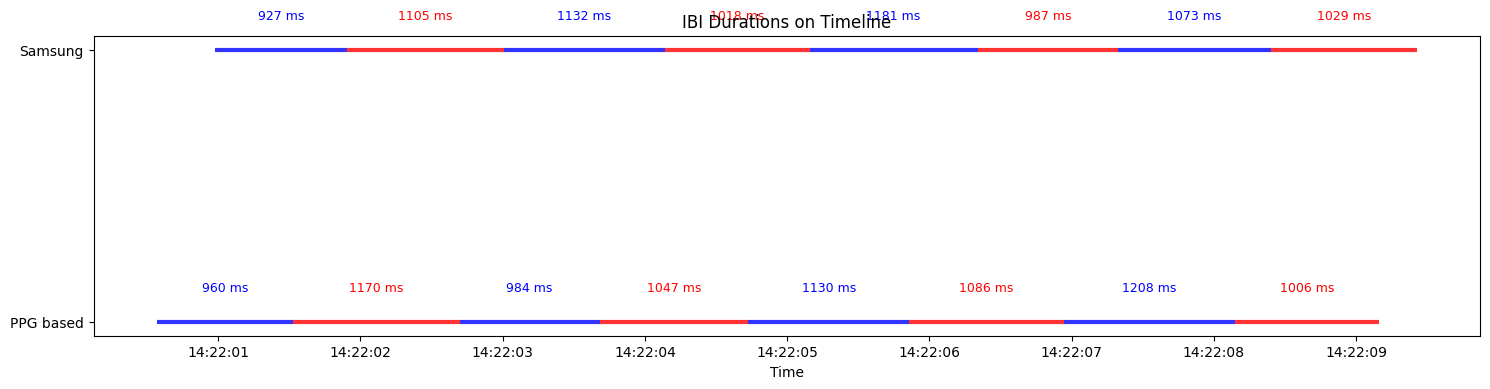

In [8]:
def plot_ibi_spans(df, y_value, color1="blue", color2="red"):
    for i in range(len(df) - 1):
        start = df["datetime"].iloc[i]
        ibi_duration_ms = df["ibi"].iloc[i]
        end = start + timedelta(seconds=ibi_duration_ms / 1000.0)  # convert ms to seconds
        color = color1 if i % 2 == 0 else color2

        # Plot the line
        plt.hlines(y=y_value, xmin=start, xmax=end, color=color, alpha=0.8, linewidth=3)

        # Add text with IBI duration in ms, slightly above the line
        midpoint = start + (end - start) / 2
        plt.text(midpoint, y_value + 0.1, f"{int(ibi_duration_ms)} ms",
                 ha='center', va='bottom', fontsize=9, rotation=0, color=color)

# Time zone
tz = pytz.FixedOffset(-420)

# Filter timestamps
start_time = pd.to_datetime("2025-07-16 14:22:00").tz_localize(tz)
end_time = pd.to_datetime("2025-07-16 14:22:10").tz_localize(tz)

# Filter data
filtered_samsung_df = ibi_samsung_detected[
    (ibi_samsung_detected["datetime"] >= start_time) &
    (ibi_samsung_detected["datetime"] <= end_time)
]

filtered_ppg_df = ppg_ibi_detection[
    (ppg_ibi_detection["datetime"] >= start_time) &
    (ppg_ibi_detection["datetime"] <= end_time)
]

# Plotting
plt.figure(figsize=[15, 4])
plot_ibi_spans(filtered_samsung_df, y_value=1)
plot_ibi_spans(filtered_ppg_df, y_value=0)

plt.yticks([1, 0], ["Samsung", "PPG based"])
plt.xlabel("Time")
plt.title("IBI Durations on Timeline")
plt.tight_layout()
plt.show()


/var/folders/_k/xwx57v7s6j779s59pcpbc5r00000gn/T/ipykernel_21940/232236139.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_ppg_df["datetime"] = filtered_ppg_df["datetime"] + pd.Timedelta("0 days 00:00:07.612000") ## 14:25:00 / 14:26:59


2025-07-16 14:26:24.644000-07:00
2025-07-16 14:26:49.269000-07:00
-1 days +23:59:35.375000


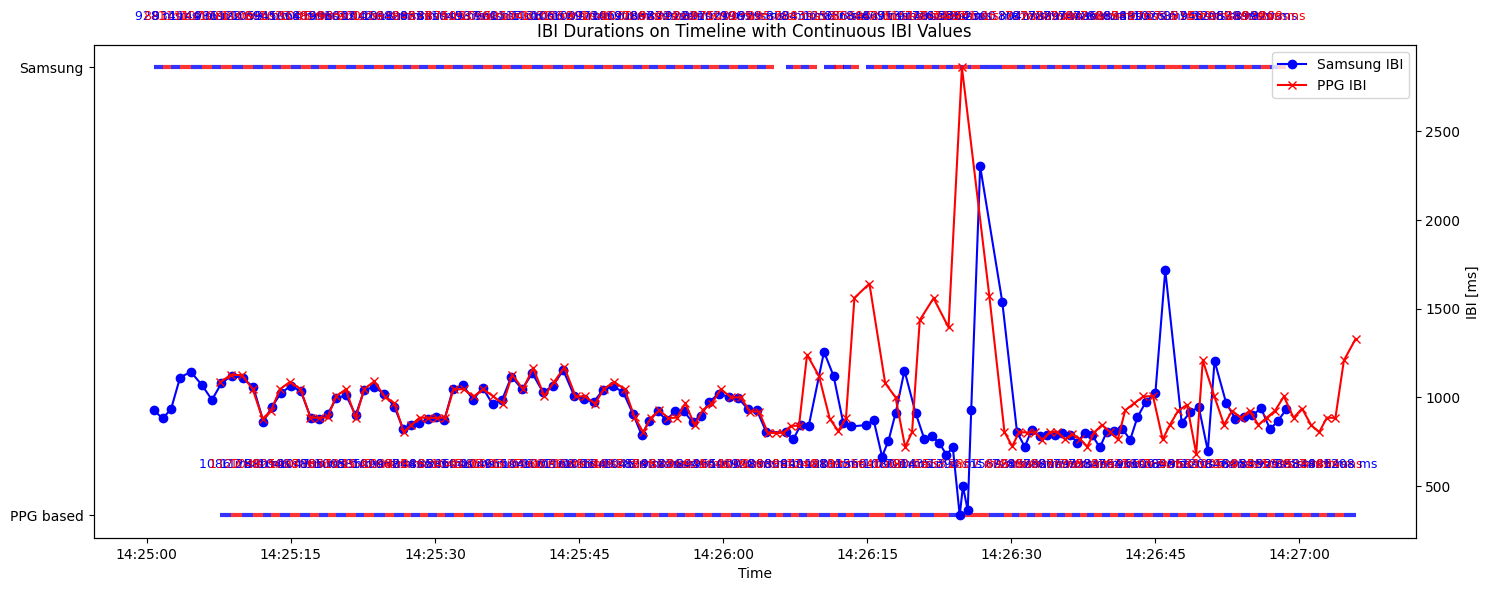

In [17]:
def plot_ibi_spans(df, y_value, color1="blue", color2="red"):
    for i in range(len(df) - 1):
        start = df["datetime"].iloc[i]
        ibi_duration_ms = df["ibi"].iloc[i]
        end = start + timedelta(seconds=ibi_duration_ms / 1000.0)  # convert ms to seconds
        color = color1 if i % 2 == 0 else color2

        # Plot the line
        plt.hlines(y=y_value, xmin=start, xmax=end, color=color, alpha=0.8, linewidth=3)

        # Add text with IBI duration in ms, slightly above the line
        midpoint = start + (end - start) / 2
        plt.text(midpoint, y_value + 0.1, f"{int(ibi_duration_ms)} ms",
                 ha='center', va='bottom', fontsize=9, rotation=0, color=color)

# Time zone
tz = pytz.FixedOffset(-420)

# Filter timestamps
start_time = pd.to_datetime("2025-07-16 14:25:00").tz_localize(tz)
end_time = pd.to_datetime("2025-07-16 14:26:59").tz_localize(tz)

# Filter data
filtered_samsung_df = ibi_samsung_detected[
    (ibi_samsung_detected["datetime"] >= start_time) &
    (ibi_samsung_detected["datetime"] <= end_time)
]

filtered_ppg_df = ppg_ibi_detection[
    (ppg_ibi_detection["datetime"] >= start_time) &
    (ppg_ibi_detection["datetime"] <= end_time)
]

#filtered_ppg_df["datetime"] = filtered_ppg_df["datetime"] + pd.Timedelta("0 days 00:00:08.612000") #Minute 22
filtered_ppg_df["datetime"] = filtered_ppg_df["datetime"] + pd.Timedelta("0 days 00:00:07.612000") ## 14:25:00 / 14:26:59


# Create plot
fig, ax1 = plt.subplots(figsize=[15, 6])

# Discrete IBI spans (on categorical y-axis)
plot_ibi_spans(filtered_samsung_df, y_value=1)
plot_ibi_spans(filtered_ppg_df, y_value=0)

print(filtered_samsung_df['datetime'][filtered_samsung_df['ibi'].idxmin()])
print(filtered_ppg_df['datetime'][filtered_ppg_df['ibi'].idxmin()])
print(filtered_samsung_df['datetime'][filtered_samsung_df['ibi'].idxmin()] - filtered_ppg_df['datetime'][filtered_ppg_df['ibi'].idxmin()])


# Continuous plot overlay (on second y-axis)
ax2 = ax1.twinx()
ax2.plot(filtered_samsung_df["datetime"], filtered_samsung_df["ibi"], label="Samsung IBI", color="blue", marker="o")
ax2.plot(filtered_ppg_df["datetime"], filtered_ppg_df["ibi"], label="PPG IBI", color="red", marker="x")
ax2.set_ylabel("IBI [ms]")
ax2.legend(loc="upper right")

# Set y-ticks for discrete tracks
ax1.set_yticks([1, 0])
ax1.set_yticklabels(["Samsung", "PPG based"])

ax1.set_xlabel("Time")
ax1.set_title("IBI Durations on Timeline with Continuous IBI Values")
fig.tight_layout()
plt.show()


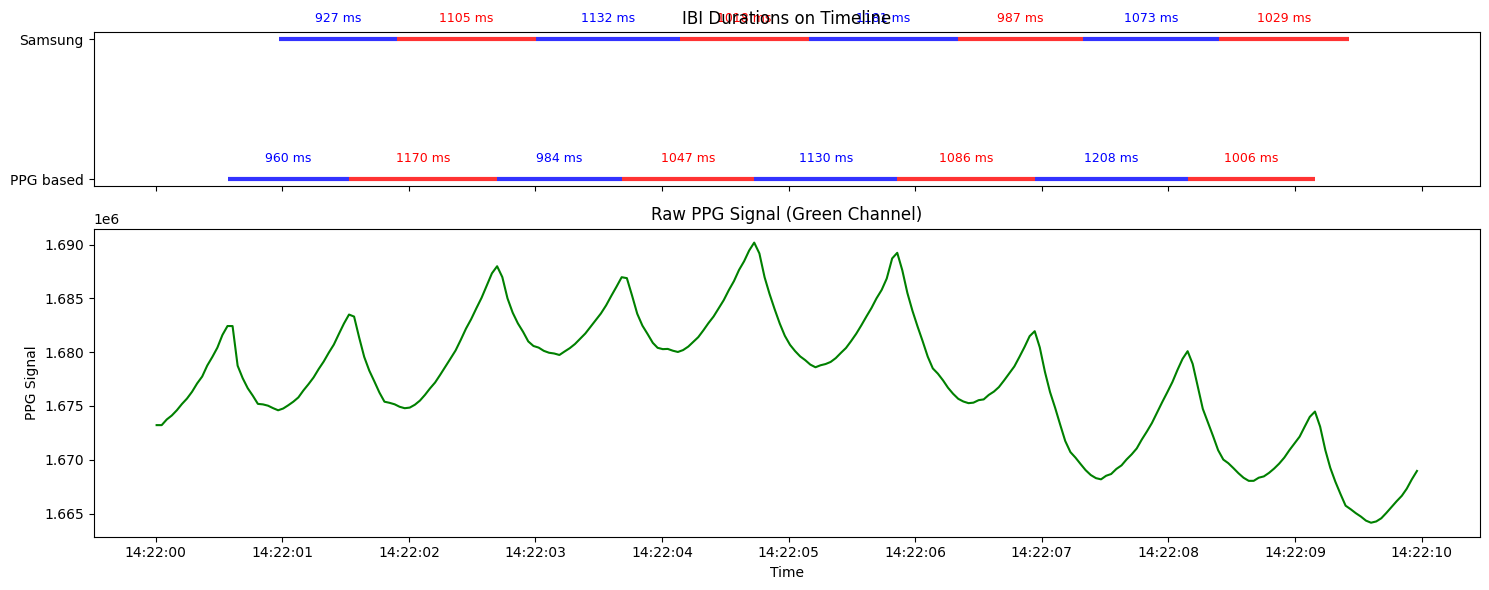

In [11]:
def plot_ibi_spans(df, y_value, ax, color1="blue", color2="red"):
    for i in range(len(df) - 1):
        start = df["datetime"].iloc[i]
        ibi_duration_ms = df["ibi"].iloc[i]
        end = start + timedelta(seconds=ibi_duration_ms / 1000.0)
        color = color1 if i % 2 == 0 else color2

        # Line span
        ax.hlines(y=y_value, xmin=start, xmax=end, color=color, alpha=0.8, linewidth=3)

        # Text annotation
        midpoint = start + (end - start) / 2
        ax.text(midpoint, y_value + 0.1, f"{int(ibi_duration_ms)} ms",
                ha='center', va='bottom', fontsize=9, rotation=0, color=color)

# Time zone
tz = pytz.FixedOffset(-420)
start_time = pd.to_datetime("2025-07-16 14:22:00").tz_localize(tz)
end_time = pd.to_datetime("2025-07-16 14:22:10").tz_localize(tz)

# Filter datasets
filtered_samsung_df = ibi_samsung_detected[
    (ibi_samsung_detected["datetime"] >= start_time) &
    (ibi_samsung_detected["datetime"] <= end_time)
]
filtered_ppg_df = ppg_ibi_detection[
    (ppg_ibi_detection["datetime"] >= start_time) &
    (ppg_ibi_detection["datetime"] <= end_time)
]
filtered_ppg_signal = ppg_data[
    (ppg_data["datetime"] >= start_time) &
    (ppg_data["datetime"] <= end_time)
]

# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=[15, 6], sharex=True, height_ratios=[1, 2])

# Plot IBI spans
plot_ibi_spans(filtered_samsung_df, y_value=1, ax=ax1)
plot_ibi_spans(filtered_ppg_df, y_value=0, ax=ax1)

ax1.set_yticks([1, 0])
ax1.set_yticklabels(["Samsung", "PPG based"])
ax1.set_title("IBI Durations on Timeline")

# Plot raw PPG signal
ax2.plot(filtered_ppg_signal["datetime"], filtered_ppg_signal["ppg_green_value"], color="green")
ax2.set_ylabel("PPG Signal")
ax2.set_title("Raw PPG Signal (Green Channel)")

plt.xlabel("Time")
plt.tight_layout()
plt.show()


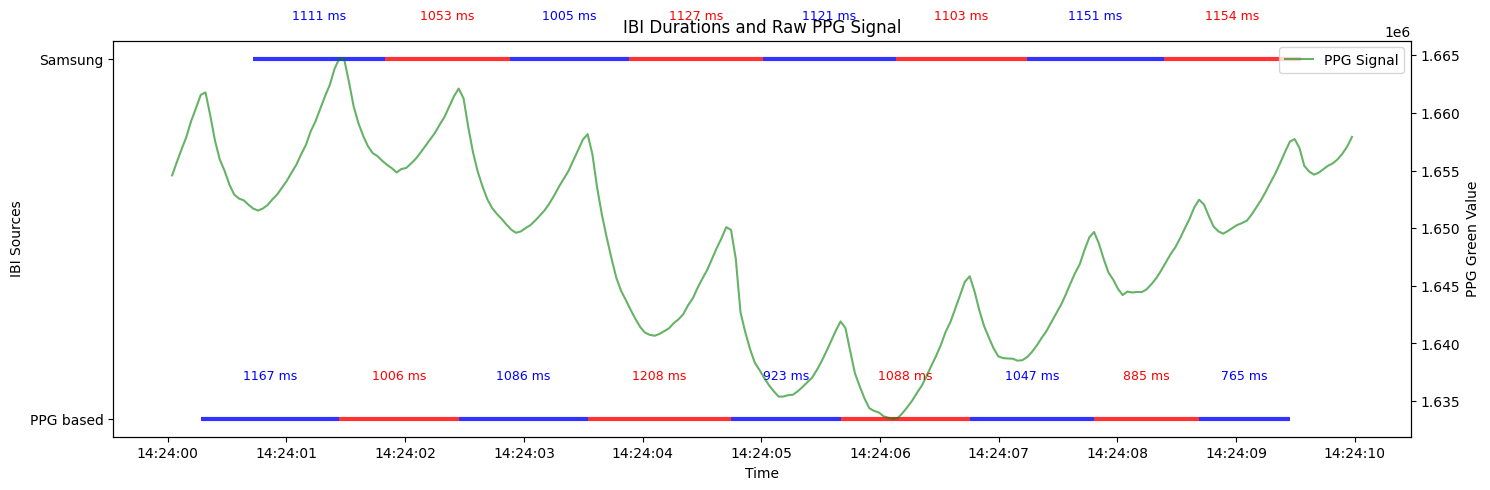

In [12]:
def plot_ibi_spans(df, y_value, ax, color1="blue", color2="red"):
    for i in range(len(df) - 1):
        start = df["datetime"].iloc[i]
        ibi_duration_ms = df["ibi"].iloc[i]
        end = start + timedelta(seconds=ibi_duration_ms / 1000.0)
        color = color1 if i % 2 == 0 else color2

        # Line span
        ax.hlines(y=y_value, xmin=start, xmax=end, color=color, alpha=0.8, linewidth=3)

        # Text annotation
        midpoint = start + (end - start) / 2
        ax.text(midpoint, y_value + 0.1, f"{int(ibi_duration_ms)} ms",
                ha='center', va='bottom', fontsize=9, rotation=0, color=color)

# Time zone
tz = pytz.FixedOffset(-420)
start_time = pd.to_datetime("2025-07-16 14:24:00").tz_localize(tz)
end_time = pd.to_datetime("2025-07-16 14:24:10").tz_localize(tz)

# Filter datasets
filtered_samsung_df = ibi_samsung_detected[
    (ibi_samsung_detected["datetime"] >= start_time) &
    (ibi_samsung_detected["datetime"] <= end_time)
]
filtered_ppg_df = ppg_ibi_detection[
    (ppg_ibi_detection["datetime"] >= start_time) &
    (ppg_ibi_detection["datetime"] <= end_time)
]
filtered_ppg_signal = ppg_data[
    (ppg_data["datetime"] >= start_time) &
    (ppg_data["datetime"] <= end_time)
]

# Create main plot
fig, ax1 = plt.subplots(figsize=[15, 5])

# Plot IBI spans
plot_ibi_spans(filtered_samsung_df, y_value=1, ax=ax1)
plot_ibi_spans(filtered_ppg_df, y_value=0, ax=ax1)

# Set labels for IBI span y-axis
ax1.set_yticks([1, 0])
ax1.set_yticklabels(["Samsung", "PPG based"])
ax1.set_ylabel("IBI Sources")
ax1.set_title("IBI Durations and Raw PPG Signal")
ax1.set_xlabel("Time")

# Create secondary y-axis for continuous PPG signal
ax2 = ax1.twinx()
ax2.plot(filtered_ppg_signal["datetime"], filtered_ppg_signal["ppg_green_value"], color="green", alpha=0.6, label="PPG Signal")
ax2.set_ylabel("PPG Green Value")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()


In [14]:
def find_best_shift(ibi1, ibi2, max_shift=30):
    """
    Find the shift (positive or negative) that minimizes the sum of squared differences
    between two IBI sequences of equal length.
    """
    min_error = float('inf')
    best_shift = 0

    n = min(len(ibi1), len(ibi2))

    for shift in range(-max_shift, max_shift + 1):
        if shift < 0:
            # Shift ibi1 right
            x = ibi1[-shift:n]
            y = ibi2[0:n+shift]
        elif shift > 0:
            # Shift ibi2 right
            x = ibi1[0:n-shift]
            y = ibi2[shift:n]
        else:
            x = ibi1[:n]
            y = ibi2[:n]

        # Ensure x and y have same length
        length = min(len(x), len(y))
        x = x[:length]
        y = y[:length]

        error = np.sum((x.values - y.values) ** 2)
        if error < min_error:
            min_error = error
            best_shift = shift

    return best_shift, min_error

In [15]:
# Time zone
tz = pytz.FixedOffset(-420)
start_time = pd.to_datetime("2025-07-16 14:22:00").tz_localize(tz)
end_time = pd.to_datetime("2025-07-16 14:24:59").tz_localize(tz)

# Filter datasets
filtered_samsung_df = ibi_samsung_detected[
    (ibi_samsung_detected["datetime"] >= start_time) &
    (ibi_samsung_detected["datetime"] <= end_time)
]
filtered_ppg_df = ppg_ibi_detection[
    (ppg_ibi_detection["datetime"] >= start_time) &
    (ppg_ibi_detection["datetime"] <= end_time)
]

filtered_samsung_df
filtered_ppg_df


,PPG_Raw,PPG_Clean,PPG_Rate,PPG_Quality,PPG_Peaks,datetime,ibi
1716,1682432,5563.702083,57.692308,0.930529,1,2025-07-16 14:22:00.567000-07:00,960.0
1740,1683499,5559.472324,62.500000,0.901441,1,2025-07-16 14:22:01.527000-07:00,1170.0
1769,1687990,6009.255089,51.724138,0.905240,1,2025-07-16 14:22:02.697000-07:00,984.0
1793,1686971,4273.630476,62.500000,0.910865,1,2025-07-16 14:22:03.681000-07:00,1047.0
1819,1690188,6389.682321,57.692308,0.900204,1,2025-07-16 14:22:04.728000-07:00,1130.0
...,...,...,...,...,...,...,...
6024,1734331,2841.615201,62.500000,0.919480,1,2025-07-16 14:24:53.909000-07:00,886.0
6046,1737484,3294.778040,68.181818,0.928416,1,2025-07-16 14:24:54.795000-07:00,924.0
6069,1738944,4676.887193,65.217391,0.910269,1,2025-07-16 14:24:55.719000-07:00,1129.0
6097,1737327,5639.457480,53.571429,0.901064,1,2025-07-16 14:24:56.848000-07:00,1166.0


In [16]:
best_shift, error = find_best_shift(filtered_samsung_df["ibi"], filtered_ppg_df["ibi"])
print(f"Best shift: {best_shift} with total squared error: {error}")

Best shift: -8 with total squared error: 1239472.0
